# Extended Data Figure 8

In [1]:
import matplotlib as mpl
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy import stats

mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False


In [2]:
# Specify data structure (for 30°/s edges):
fs = 1000 # sampling frequency (Hz)
stims = ['on', 'off'] # stimuli
dirs = ['pd', 'nd']   # directions
tf = 8000             # timeframe (ms)

# Load input cell voltage data from folder 'Fig. 3':
os.chdir('../Fig. 3')
Mi9a = np.load('fig3_Mi9.npy')
Tm3a = np.load('fig3_Tm3.npy')
Mi1a = np.load('fig3_Mi1.npy')
Mi4a = np.load('fig3_Mi4.npy')
C3a = np.load('fig3_C3.npy')


# Average input cell voltage data:
Mi9_ = np.nanmean(Mi9a, axis=1)
Tm3_ = np.nanmean(Tm3a, axis=1)
Mi1_ = np.nanmean(Mi1a, axis=1)
Mi4_ = np.nanmean(Mi4a, axis=1)
C3_ = np.nanmean(C3a, axis=1)

# Load T4 cell voltage data:
T4va = np.load('fig3_T4v.npy')

# Average T4 cell voltage data:
T4v = T4va.mean(0)
T4v_sem = stats.sem(T4va, axis =0, nan_policy='omit')

# Load LED data:
led = np.load('fig3_led.npy')
os.chdir('../ED Fig. 8')

# Initialize arrays:
Mi9 = np.full((len(stims), len(dirs), tf), np.nan)
Tm3 = np.full((len(stims), len(dirs), tf), np.nan)
Mi1 = np.full((len(stims), len(dirs), tf), np.nan)
Mi4 = np.full((len(stims), len(dirs), tf), np.nan)
C3 = np.full((len(stims), len(dirs), tf), np.nan)
LED = np.full((len(stims), len(dirs), tf), np.nan)
T4model = np.full_like(T4v, np.nan)

gMi9 = np.full_like(Mi9, np.nan)
gTm3 = np.full_like(Tm3, np.nan)
gMi1 = np.full_like(Mi1, np.nan)
gMi4 = np.full_like(Mi4, np.nan)
gC3 = np.full_like(C3, np.nan)

gtotal = np.full_like(T4v, np.nan)

# Normalize and shift data for PD and ND:
def normalize(a):
    anorm=a-np.min(a)
    anorm=anorm/np.max(anorm)
    return anorm

def shift_data(data, shift):
    shifted = np.roll(data, shift)
    if shift > 0:
        shifted[0:shift] = data[0]
    if shift < 0:
        shifted[int(len(data))+shift:int(len(data))] = data[-1]
    return shifted

def pdnd_shift(Mi9_=normalize(Mi9_), Tm3_=normalize(Tm3_), Mi1_=normalize(Mi1_), Mi4_=normalize(Mi4_), C3_=normalize(C3_)):
    for s in range(len(stims)):
        shift = int(4.8*fs/30) # assuming an inter-ommatidial angle of 4.8°
        for idxd, d in enumerate(dirs):
            Tm3[s,idxd] = Tm3_[s]
            Mi1[s,idxd] = Mi1_[s]
            
            if d == 'pd':
                Mi9[s,idxd] = shift_data(Mi9_[s], -shift)
                Mi4[s,idxd] = shift_data(Mi4_[s], +shift)
                C3[s,idxd] = shift_data(C3_[s], +shift)
                
            elif d == 'nd':
                Mi9[s,idxd] = shift_data(Mi9_[s], +shift)
                Mi4[s,idxd] = shift_data(Mi4_[s], -shift)
                C3[s,idxd] = shift_data(C3_[s], -shift)                 
                
    return Mi9, Tm3, Mi1, Mi4, C3

# Shift:
Mi9, Tm3, Mi1, Mi4, C3 = pdnd_shift()


# Initialize free parameters:
# Synaptic weights/gains:
Mi9gain = 0.92
Tm3gain = 0.35
Mi1gain = 0.65
Mi4gain = 1.1
C3gain = 1.49

# Thresholds:
Mi9trld = 0.20
Tm3trld = 0.35
Mi1trld = 0.88 
Mi4trld = 0.44
C3trld = 0.70

# Leak conductance:
gleak = 0.50
Eleak = -65.0

# Constants:
EGlu = -71.0    # Glutamate current reversal potential (mV)
EGABA   = -68.0 # GABA current reversal potential (mV)
EnAChR = -21.0  # Nicotinic acetycholine current reversal potential (mV)

# Model:
vs = [Mi9, Tm3, Mi1, Mi4, C3] # input cell voltages
gs = [gMi9, gTm3, gMi1, gMi4, gC3] # conductances
onoff = [1, 1, 1, 1, 1, 1] # To switch cells on/off 1/0 [Mi9, Mi1, Tm3, Mi4, C3]:

params = np.array([Mi9gain, Tm3gain, Mi1gain, Mi4gain, C3gain,
                       Mi9trld, Tm3trld, Mi1trld, Mi4trld, C3trld,
                       Eleak, gleak])

# Rectilinear transfer function:
def rect(x,thrld):
    result = x - thrld
    result = result * (result>0)
    result = result + thrld
    return result

# Run the simulation:
def run_model(onoff=[1,1,1,1,1], params=params):
    # Assigns conductances:
    params = np.asarray(params)

    for idx, g in enumerate(gs):
        g[:] = onoff[idx] * params[idx] * rect(vs[idx][:] - params[idx+5], 0)
    T4model[:] = EGlu * gMi9 + EnAChR * (gTm3+gMi1) + EGABA * (gMi4+gC3) + params[10] * params[11]
        
    gtotal[:] = gMi1 + gMi4 + gMi9 + gC3 + gTm3 + gleak
    T4model[:] = T4model[:] / gtotal[:] 
    rin = 1 / gtotal
    
    return T4model, rin

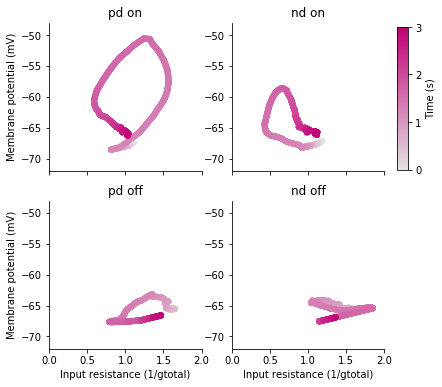

In [3]:
# Extended Data Figure 8:
model_cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap', ['#e3e3e3', '#C20078'], N=256)

ds = 15  # downsample for plotting
m = 2499 # margin

fig, ax = plt.subplots(2,2, figsize=(6,6), sharex=True)
time = np.arange(0,len(T4v[0,0,m:-m])/fs,0.001)

model, rin = run_model(onoff=[1, 1, 1, 1, 1], params=params)
for idxs, s in enumerate(stims):
    for idxg, g in enumerate(gs):
        for idxd, d in enumerate(dirs):
            
            x = rin[0+idxs,idxd,m:-m:ds]
            y = model[0+idxs,idxd,m:-m:ds]
            t_stim = time[::ds]

            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            # Create a continuous norm to map from data points to colors
            norm = plt.Normalize(t_stim.min(), t_stim.max())
            lc = LineCollection(segments, cmap=model_cmap, norm=norm)
            
            # Set the values used for colormapping
            lc.set_array(t_stim)
            lc.set_linewidth(6)
            lc.set_capstyle('round')
            
            line = ax[idxs,idxd].add_collection(lc)
            
            ax[idxs,idxd].set_ylim(-72, -48)
            ax[idxs,idxd].set_xlim(0, 2)
            ax[idxs,idxd].set_title("{0} {1}".format(dirs[idxd], stims[idxs]))
            #ax[1+idxs*2,idxd].set(adjustable='box', aspect='equal')
    
for i in [0,1]:
    ax[i,0].set_ylabel('Membrane potential (mV)')
    
for i in [0,1]:
    ax[1,i].set_xlabel('Input resistance (1/gtotal)')
    
cbar_ax = fig.add_axes([0.93, 0.54, 0.025, 0.33])
cb = fig.colorbar(lc, cax=cbar_ax)
cb.set_label("Time (s)")
cb.set_ticks([0, 1, 2, 3])

#plt.savefig("edfig8.pdf")